In [ ]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Environment is working!")
print("Pandas     :", pd.__version__)
print("NumPy      :", np.__version__)
print("Matplotlib :", plt.__version__)
print("Seaborn    :", sns.__version__)
print("Scikit-learn:", sklearn.__version__)

Environment is working!
Pandas     : 3.0.3
NumPy      : 2.4.6


AttributeError: module 'matplotlib.pyplot' has no attribute '__version__'

In [4]:
df = pd.read_csv("../datasets/heart.csv")
print(df.head(5))
print('shape of dataset: ',df.shape)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  num  
0    3.0  0.0  6.0    0  
1    2.0  3.0  3.0    2  
2    2.0  2.0  7.0    1  
3    3.0  0.0  3.0    0  
4    1.0  0.0  3.0    0  
shape of dataset:  (303, 14)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 35.0 KB


In [6]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

summary

,Data Type,Unique Values,Missing Values
age,float64,41,0
sex,float64,2,0
cp,float64,4,0
trestbps,float64,50,0
chol,float64,152,0
fbs,float64,2,0
restecg,float64,3,0
thalach,float64,91,0
exang,float64,2,0
oldpeak,float64,40,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print("ca values:")
print(df["ca"].value_counts())

print("\nthal values:")
print(df["thal"].value_counts())

ca values:
ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

thal values:
thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64


In [9]:
print(df["num"].value_counts().sort_index())

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [10]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


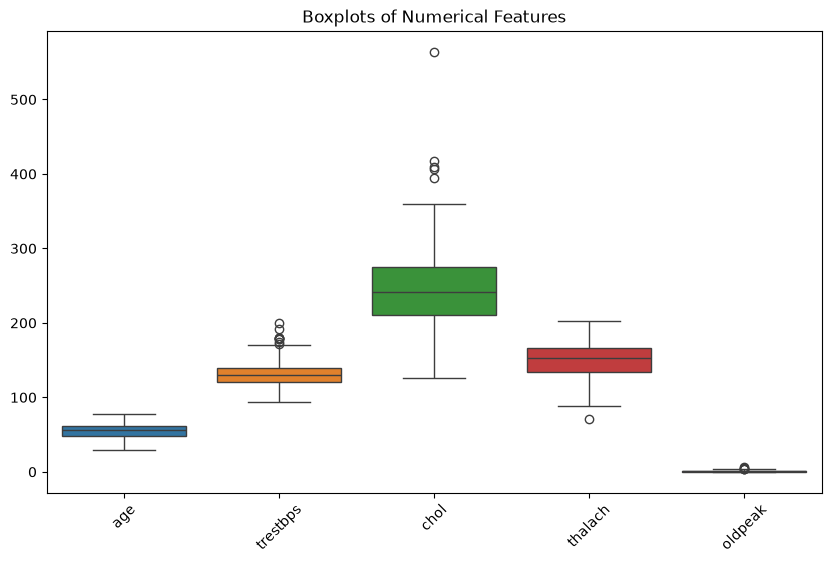

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[numerical_features])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.show()

In [12]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for col in categorical_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- sex ---
sex
1.0    206
0.0     97
Name: count, dtype: int64

--- cp ---
cp
4.0    144
3.0     86
2.0     50
1.0     23
Name: count, dtype: int64

--- fbs ---
fbs
0.0    258
1.0     45
Name: count, dtype: int64

--- restecg ---
restecg
0.0    151
2.0    148
1.0      4
Name: count, dtype: int64

--- exang ---
exang
0.0    204
1.0     99
Name: count, dtype: int64

--- slope ---
slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

--- ca ---
ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

--- thal ---
thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64


In [13]:
df[["ca", "thal"]] = df[["ca", "thal"]].replace("?", np.nan)

In [14]:
df[["ca","thal"]].isnull().sum()

ca      4
thal    2
dtype: int64